# Invoice Chaser — Data Analysis

**Purpose:** validate the assumptions our agent's logic is built on, using the real IBM Accounts Receivable dataset — not guesses.

This notebook covers:
1. Dataset overview
2. Payment behavior distribution (`DaysLate`)
3. Validating our client risk-score thresholds (`src/client_risk.py`)
4. Disputed vs. non-disputed payment behavior
5. Country-level payment patterns
6. End-to-end sanity check of the pipeline (`src/data_loader.py`, `src/client_risk.py`)

Run this from the **repo root** — it expects `data/accounts_receivable.csv` and imports directly from `src/`.


## 1. Setup & Data Overview

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Import your uploaded modules (same folder as notebook)
from data_loader import load_invoices, get_open_invoices, reminder_tier, DEFAULT_DATA_PATH
from client_risk import compute_client_risk, _risk_level

# Pandas + Matplotlib settings
pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (9, 4)

# Since you uploaded accounts_receivables.csv directly, override DEFAULT_DATA_PATH
DEFAULT_DATA_PATH = "/content/accounts_receivable.csv"

# Load your data using file
df = load_invoices(DEFAULT_DATA_PATH)
print(f"{len(df)} invoices loaded")
df.head()


2466 invoices loaded


,countryCode,customerID,PaperlessDate,invoiceNumber,InvoiceDate,DueDate,InvoiceAmount,Disputed,SettledDate,PaperlessBill,DaysToSettle,DaysLate
0,391,0379-NEVHP,2013-04-06,611365,2013-01-02,2013-02-01,55.94,No,2013-01-15,Paper,13,0
1,406,8976-AMJEO,2012-03-03,7900770,2013-01-26,2013-02-25,61.74,Yes,2013-03-03,Electronic,36,6
2,391,2820-XGXSB,2012-01-26,9231909,2013-07-03,2013-08-02,65.88,No,2013-07-08,Electronic,5,0
3,406,9322-YCTQO,2012-04-06,9888306,2013-02-10,2013-03-12,105.92,No,2013-03-17,Electronic,35,5
4,818,6627-ELFBK,2012-11-26,15752855,2012-10-25,2012-11-24,72.27,Yes,2012-11-28,Paper,34,4


In [2]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2466 entries, 0 to 2465
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   countryCode    2466 non-null   int64         
 1   customerID     2466 non-null   object        
 2   PaperlessDate  2466 non-null   datetime64[ns]
 3   invoiceNumber  2466 non-null   int64         
 4   InvoiceDate    2466 non-null   datetime64[ns]
 5   DueDate        2466 non-null   datetime64[ns]
 6   InvoiceAmount  2466 non-null   float64       
 7   Disputed       2466 non-null   object        
 8   SettledDate    2466 non-null   datetime64[ns]
 9   PaperlessBill  2466 non-null   object        
 10  DaysToSettle   2466 non-null   int64         
 11  DaysLate       2466 non-null   int64         
dtypes: datetime64[ns](4), float64(1), int64(4), object(3)
memory usage: 231.3+ KB


In [3]:
df.describe(include="all").T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
countryCode,2466.0,NaN,NaN,NaN,620.446067,391.0,406.0,770.0,818.0,897.0,215.93361
customerID,2466,100,9149-MATVB,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PaperlessDate,2466,NaN,NaN,NaN,2012-12-24 15:41:53.868613120,2012-01-09 00:00:00,2012-07-31 00:00:00,2012-12-31 00:00:00,2013-06-03 00:00:00,2013-11-27 00:00:00,NaN
invoiceNumber,2466.0,NaN,NaN,NaN,4978430514.972425,611365.0,2528853991.0,4964228313.5,7494512439.0,9990243864.0,2884271865.47071
InvoiceDate,2466,NaN,NaN,NaN,2012-12-19 14:56:21.021897728,2012-01-03 00:00:00,2012-07-02 00:00:00,2012-12-22 00:00:00,2013-06-05 00:00:00,2013-12-02 00:00:00,NaN
DueDate,2466,NaN,NaN,NaN,2013-01-18 14:56:21.021897728,2012-02-02 00:00:00,2012-08-01 00:00:00,2013-01-21 00:00:00,2013-07-05 00:00:00,2014-01-01 00:00:00,NaN
InvoiceAmount,2466.0,NaN,NaN,NaN,59.895856,5.26,46.4,60.56,73.765,128.28,20.435838
Disputed,2466,2,No,1905,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SettledDate,2466,NaN,NaN,NaN,2013-01-15 01:36:56.058394112,2012-01-13 00:00:00,2012-07-30 00:00:00,2013-01-15 00:00:00,2013-07-02 00:00:00,2014-01-09 00:00:00,NaN
PaperlessBill,2466,2,Paper,1263,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Sanity checks:**
- No missing values expected across all 12 columns.
- Every invoice should have the same payment term — confirm below.


In [4]:
term = (df["DueDate"] - df["InvoiceDate"]).dt.days
term.value_counts()


,count
30,2466


## 2. Payment Behavior — `DaysLate` Distribution

This is the number that drives everything downstream: overdue detection, reminder tone, and risk scoring.


In [5]:
df["DaysLate"].describe()


,DaysLate
count,2466.000000
mean,3.442417
std,6.290607
min,0.000000
25%,0.000000
50%,0.000000
75%,5.000000
max,45.000000


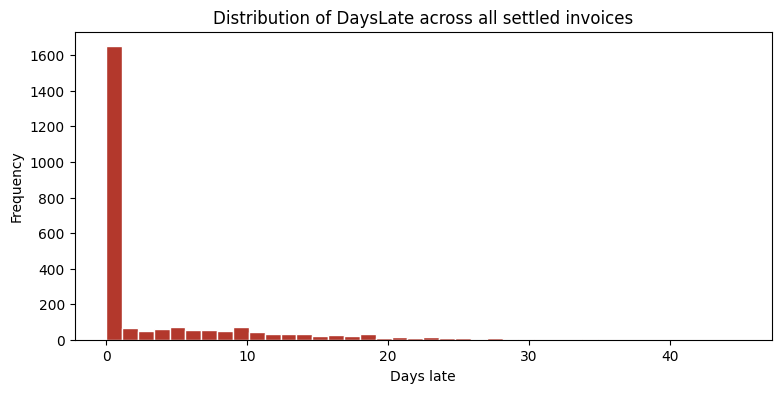

In [6]:
fig, ax = plt.subplots()
df["DaysLate"].plot(kind="hist", bins=40, ax=ax, color="#B3382C", edgecolor="white")
ax.set_title("Distribution of DaysLate across all settled invoices")
ax.set_xlabel("Days late")
plt.show()


In [7]:
for p in [25, 50, 60, 75, 85, 90, 95, 99]:
    print(f"{p}th percentile: {df['DaysLate'].quantile(p/100):.1f} days")


25th percentile: 0.0 days
50th percentile: 0.0 days
60th percentile: 0.0 days
75th percentile: 5.0 days
85th percentile: 10.0 days
90th percentile: 13.0 days
95th percentile: 18.0 days
99th percentile: 26.0 days


**Takeaway:** most invoices settle on time or very close to it (median = 0 days late). The distribution has a long right tail — a small share of invoices are dramatically later than the rest. This is exactly the kind of distribution that justifies *tiered* handling instead of one-size-fits-all reminders.


## 3. Validating Our Risk-Score Thresholds

`src/client_risk.py` currently classifies a client's payment history as:

| Tier | Rule |
|---|---|
| Low | avg days late ≤ 2 |
| Medium | avg days late ≤ 10 |
| High | avg days late > 10 |

These started as reasonable-sounding defaults. Let's check where they actually fall on the real distribution, and how many clients land in each tier.


In [8]:
for cutoff in [2, 10]:
    pct = (df["DaysLate"] <= cutoff).mean() * 100
    print(f"DaysLate <= {cutoff}: {pct:.1f}% of all invoices fall at or under this")


DaysLate <= 2: 69.5% of all invoices fall at or under this
DaysLate <= 10: 86.3% of all invoices fall at or under this


In [9]:
snapshot_date = df["SettledDate"].max().strftime("%Y-%m-%d")
risk_df = compute_client_risk(df, snapshot_date)

print(f"Snapshot date used: {snapshot_date}")
print(f"Clients scored: {len(risk_df)}\n")
print(risk_df["risk_level"].value_counts())


Snapshot date used: 2014-01-09
Clients scored: 100

risk_level
Low       52
Medium    37
High      11
Name: count, dtype: int64


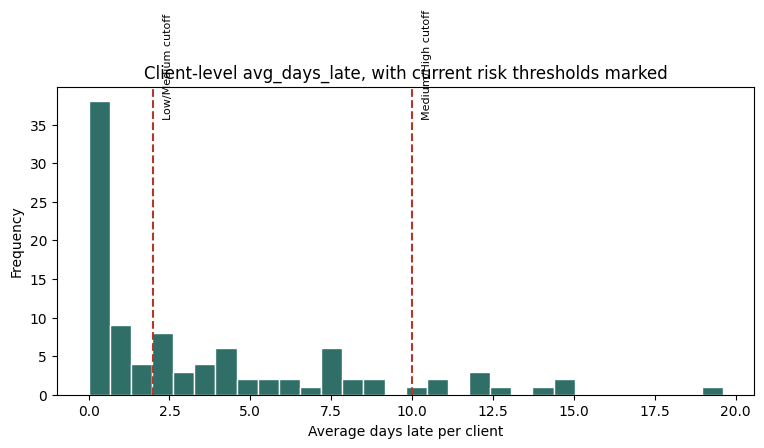

In [10]:
fig, ax = plt.subplots()
risk_df["avg_days_late"].plot(kind="hist", bins=30, ax=ax, color="#2F6F68", edgecolor="white")
for cutoff, label in [(2, "Low/Medium cutoff"), (10, "Medium/High cutoff")]:
    ax.axvline(cutoff, color="#B3382C", linestyle="--")
    ax.text(cutoff + 0.3, ax.get_ylim()[1]*0.9, label, rotation=90, fontsize=8)
ax.set_title("Client-level avg_days_late, with current risk thresholds marked")
ax.set_xlabel("Average days late per client")
plt.show()


**Conclusion:** *(fill in after running — see the printed tier breakdown above)*. If the `High` tier ends up capturing roughly the worst-behaving 10–15% of clients rather than, say, half of them, the thresholds are doing their job: flagging genuine outliers instead of over-flagging everyone. If the split looks off (e.g. almost no one lands in `Medium`, or `High` captures 40%+ of clients), that's a sign the cutoffs need adjusting — change the numbers in `_risk_level()` in `src/client_risk.py` and re-run this cell.


## 4. Disputed vs. Non-Disputed Invoices

`Disputed` is a column we're not using anywhere in the agent's logic yet. Does it actually correlate with late payment? If so, our action plan / risk scoring should probably account for it.


In [11]:
dispute_compare = df.groupby("Disputed")["DaysLate"].agg(["mean", "median", "count"])
dispute_compare


,mean,median,count
Disputed,,,
No,1.929659,0.0,1905
Yes,8.579323,7.0,561


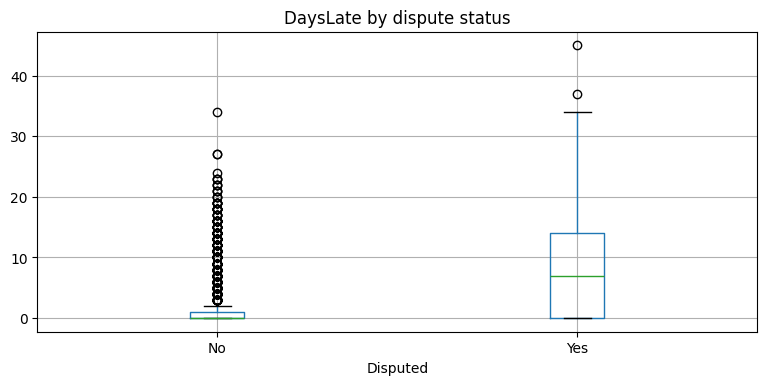

In [12]:
fig, ax = plt.subplots()
df.boxplot(column="DaysLate", by="Disputed", ax=ax)
ax.set_title("DaysLate by dispute status")
plt.suptitle("")
plt.show()


**Takeaway:** *(fill in after running)* — if disputed invoices are meaningfully later on average, that's a strong case for treating disputed invoices differently in the action plan (e.g. "resolve the dispute" instead of "send a firmer reminder," since a firmer tone on a genuine dispute could backfire).


## 5. Country-Level Payment Patterns


In [13]:
country_stats = df.groupby("countryCode")["DaysLate"].agg(["mean", "count"]).sort_values("mean", ascending=False)
country_stats


,mean,count
countryCode,,
818,4.816537,387
406,3.941176,561
770,3.642292,506
897,3.608586,396
391,1.853896,616


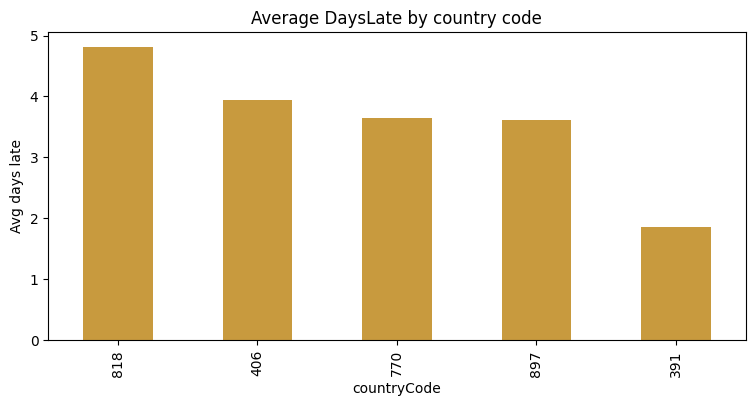

In [14]:
fig, ax = plt.subplots()
country_stats["mean"].plot(kind="bar", ax=ax, color="#C89A3E")
ax.set_title("Average DaysLate by country code")
ax.set_ylabel("Avg days late")
plt.show()


## 6. End-to-End Pipeline Sanity Check

Trace a handful of real invoices through the full pipeline — overdue detection → tier classification — and eyeball whether the output makes sense.


In [15]:
check_date = df["DueDate"].quantile(0.6).strftime("%Y-%m-%d")
open_df = get_open_invoices(df, check_date)

print(f"As of {check_date}: {len(open_df)} invoices were open, {open_df['IsOverdue'].sum()} overdue.\n")

sample = open_df[open_df["IsOverdue"]].sort_values("DaysOverdue", ascending=False).head(8).copy()
sample["Tier"] = sample["DaysOverdue"].apply(lambda d: reminder_tier(int(d)))
sample[["customerID", "invoiceNumber", "InvoiceAmount", "DaysOverdue", "Tier"]]


As of 2013-03-28: 91 invoices were open, 9 overdue.



,customerID,invoiceNumber,InvoiceAmount,DaysOverdue,Tier
1383,5613-UHVMG,5612029362,72.82,19,polite_followup
589,5573-KSOIA,2419712397,86.72,15,polite_followup
1758,8102-ABPKQ,7091388946,60.30,14,polite_followup
162,6627-ELFBK,620329407,76.50,11,polite_followup
1370,0783-PEPYR,5554040283,59.36,9,polite_followup
223,1080-NDGAE,857712918,93.39,4,gentle
793,4460-ZXNDN,3224727771,84.71,3,gentle
2333,1080-NDGAE,9390786866,74.62,2,gentle


**QA checklist — confirm manually:**
- [ ] Invoices with more `DaysOverdue` get equal-or-firmer tiers than ones with fewer (monotonic).
- [ ] No invoice shows `IsOverdue = True` with a due date in the future relative to the snapshot.
- [ ] Amounts and customer IDs match what's in the raw CSV for a couple of spot-checked rows.

If all three hold, the core pipeline is trustworthy going into the demo.


## 7. Summary for the README / Pitch

Fill these in once the notebook has been run against the real data:

- Total invoices analyzed: **___**
- Standard payment term: **___ days**
- Median days late: **___**
- % of invoices settled on time or early: **___%**
- Risk tier breakdown: Low **___%**, Medium **___%**, High **___%**
- Disputed invoices are on average **___ days later / earlier** than non-disputed ones
- Highest-risk country code: **___**

*Analysis by Eve — data analysis lead, Invoice Chaser (AWS Agents for Humans Hackathon).*
